# Task 2 — Telco Customer Churn Prediction Pipeline

**DevelopersHub Corporation — Internship Task 2**

Production-ready, end-to-end ML pipeline using **scikit-learn `Pipeline`** + **`ColumnTransformer`** on the IBM Telco Customer Churn dataset.

> Run cells **sequentially** (1 → 6). Training + grid search typically completes in a few minutes on CPU.

## Cell 1: Environment Setup & Data Acquisition

Import dependencies, configure logging, download the Telco Churn CSV from a verified public source, and load into a `DataFrame`.

In [2]:
# Cell 1 — Environment setup & data acquisition
from __future__ import annotations

import logging
import time
from pathlib import Path
from typing import Any, Dict, Tuple
from urllib.error import URLError
from urllib.request import urlretrieve

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)
logger = logging.getLogger(__name__)

RANDOM_STATE: int = 42
DATA_DIR = Path("./data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

TELCO_CSV_URLS = [
    # IBM official mirror (active as of 2025)
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv",
    # Legacy mirror (may 404)
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-ibm/master/data/Telco-Customer-Churn.csv",
]
LOCAL_CSV_PATH = DATA_DIR / "Telco-Customer-Churn.csv"
PIPELINE_ARTIFACT_PATH = Path("./telco_churn_pipeline.joblib")
TARGET_COLUMN = "Churn"
ID_COLUMN = "customerID"


def download_telco_dataset(urls: list[str], destination: Path) -> Path:
    """Download Telco CSV if not cached; try multiple verified mirrors."""
    if destination.exists():
        logger.info("Dataset already exists at %s — skipping download.", destination)
        return destination

    errors: list[str] = []
    for url in urls:
        logger.info("Trying download: %s", url)
        try:
            urlretrieve(url, destination)
            logger.info("Saved dataset to %s", destination.resolve())
            return destination
        except (URLError, OSError) as exc:
            errors.append(f"{url} -> {exc}")
            if destination.exists():
                destination.unlink()

    raise RuntimeError(
        "Failed to download Telco dataset from all mirrors:\n" + "\n".join(errors)
    )


def load_telco_dataframe(csv_path: Path) -> pd.DataFrame:
    """Load Telco churn CSV into a Pandas DataFrame."""
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    logger.info("Loaded %s rows x %s columns.", df.shape[0], df.shape[1])
    return df


csv_path = download_telco_dataset(TELCO_CSV_URLS, LOCAL_CSV_PATH)
df_raw = load_telco_dataframe(csv_path)

print(df_raw.head())
print("\nShape:", df_raw.shape)
print("\nDtypes:\n", df_raw.dtypes)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## Cell 2: Exploratory Data Analysis & Target Extraction

Clean `TotalCharges`, encode binary target, split features/target, and perform a **stratified 80/20** train-test split.

In [3]:
# Cell 2 — EDA, cleaning, target encoding, stratified split
from typing import List


def clean_telco_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Essential cleaning:
    - Convert TotalCharges to numeric (empty strings → NaN)
    - Drop rows with missing TotalCharges (typically new customers)
    """
    data = df.copy()

    if "TotalCharges" not in data.columns:
        raise ValueError("Expected column 'TotalCharges' not found.")

    data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
    missing_before = int(data["TotalCharges"].isna().sum())
    data = data.dropna(subset=["TotalCharges"]).reset_index(drop=True)
    logger.info("Dropped %s rows with invalid TotalCharges.", missing_before)

    return data


def encode_churn_target(series: pd.Series) -> pd.Series:
    """Map Churn Yes/No → 1/0."""
    mapping = {"Yes": 1, "No": 0}
    encoded = series.map(mapping)
    if encoded.isna().any():
        unknown = series[encoded.isna()].unique().tolist()
        raise ValueError(f"Unexpected Churn values: {unknown}")
    return encoded.astype(int)


def split_features_target(
    df: pd.DataFrame,
    target_col: str = TARGET_COLUMN,
    id_col: str = ID_COLUMN,
) -> Tuple[pd.DataFrame, pd.Series]:
    """Separate X and y; drop customer ID from features."""
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' missing.")

    y = encode_churn_target(df[target_col])
    X = df.drop(columns=[target_col])
    if id_col in X.columns:
        X = X.drop(columns=[id_col])
    return X, y


df_clean = clean_telco_dataframe(df_raw)
X, y = split_features_target(df_clean)

churn_rate = y.mean()
logger.info("Churn rate: %.2f%%", churn_rate * 100)
print("Class balance (Churn=1):", y.value_counts(normalize=True).round(4))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Train churn rate: {y_train.mean():.4f} | Test churn rate: {y_test.mean():.4f}")

Class balance (Churn=1): Churn
0    0.7342
1    0.2658
Name: proportion, dtype: float64
Train: 5625 samples | Test: 1407 samples
Train churn rate: 0.2658 | Test churn rate: 0.2658


## Cell 3: Building the Preprocessing & Feature Engineering Pipeline

Programmatically split **numerical** vs **categorical** columns and build a unified `ColumnTransformer`.

In [4]:
# Cell 3 — Preprocessing & feature engineering pipeline


def get_feature_column_groups(
    X: pd.DataFrame,
) -> Tuple[List[str], List[str]]:
    """Infer numerical and categorical feature names from training data."""
    numerical_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
    categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    return numerical_cols, categorical_cols


def build_preprocessor(
    numerical_cols: List[str],
    categorical_cols: List[str],
) -> ColumnTransformer:
    """
    ColumnTransformer:
      - Numerical: median imputation → StandardScaler
      - Categorical: most_frequent imputation → OneHotEncoder
    """
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", encoder),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numerical_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ],
        remainder="drop",
    )
    return preprocessor


numerical_features, categorical_features = get_feature_column_groups(X_train)
preprocessor = build_preprocessor(numerical_features, categorical_features)

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("\nPreprocessor:")
print(preprocessor)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Preprocessor:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 (

## Cell 4: Model Training, Selection, and Hyperparameter Tuning

Master `Pipeline` (preprocessor + classifier) with **`GridSearchCV`** comparing **Logistic Regression** vs **Random Forest**.

In [5]:
# Cell 4 — Model training, selection, hyperparameter tuning


def build_model_pipeline(preprocessor: ColumnTransformer) -> Pipeline:
    """Master pipeline: preprocessing + classifier placeholder."""
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, solver="liblinear"),
            ),
        ]
    )


def build_param_grid() -> List[Dict[str, Any]]:
    """
    Hyperparameter grids for two estimators in one GridSearchCV.
    Each list entry targets a different classifier.
    """
    return [
        {
            "classifier": [
                LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                    solver="liblinear",
                )
            ],
            "classifier__C": [0.01, 0.1, 1.0, 10.0],
            "classifier__penalty": ["l1", "l2"],
        },
        {
            "classifier": [RandomForestClassifier(random_state=RANDOM_STATE)],
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [None, 10, 20],
            "classifier__min_samples_split": [2, 5, 10],
        },
    ]


model_pipeline = build_model_pipeline(preprocessor)
param_grid = build_param_grid()

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    refit=True,
    verbose=1,
    return_train_score=True,
)

logger.info("Starting GridSearchCV (this may take a few minutes)…")
start_time = time.perf_counter()
grid_search.fit(X_train, y_train)
elapsed = time.perf_counter() - start_time

logger.info("GridSearchCV completed in %.2f seconds.", elapsed)
print(f"\nBest CV F1: {grid_search.best_score_:.4f}")
print(f"Best estimator: {grid_search.best_estimator_['classifier']}")
print(f"Execution time: {elapsed:.2f}s")

Fitting 5 folds for each of 26 candidates, totalling 130 fits

Best CV F1: 0.5965
Best estimator: LogisticRegression(max_iter=2000, random_state=42, solver='liblinear')
Execution time: 81.74s


## Cell 5: Comprehensive Pipeline Evaluation

Evaluate the best pipeline on the held-out test set: metrics, classification report, confusion matrix, and ROC curve.

OPTIMIZED HYPERPARAMETERS
  classifier: LogisticRegression(max_iter=2000, random_state=42, solver='liblinear')
  classifier__C: 1.0
  classifier__penalty: l2

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



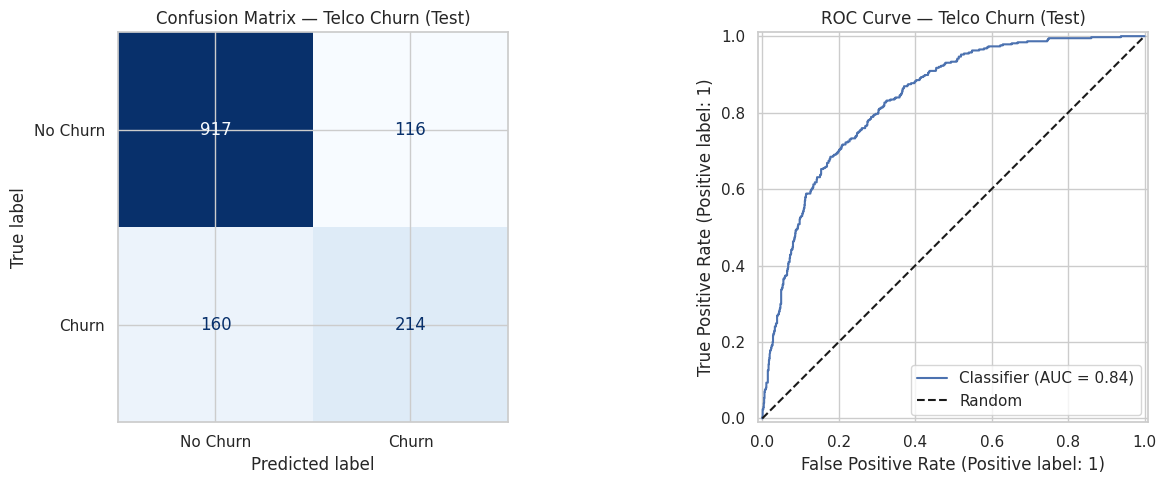

In [6]:
# Cell 5 — Comprehensive pipeline evaluation

best_pipeline: Pipeline = grid_search.best_estimator_

print("=" * 60)
print("OPTIMIZED HYPERPARAMETERS")
print("=" * 60)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT (Test Set)")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Confusion Matrix — Telco Churn (Test)")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("ROC Curve — Telco Churn (Test)")
axes[1].plot([0, 1], [0, 1], "k--", label="Random")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## Cell 6: Pipeline Serialization & Reusability Verification

Persist the full fitted pipeline with `joblib` and verify inference on **raw** customer feature rows.

In [7]:
# Cell 6 — Serialization & inference verification


def save_pipeline(pipeline: Pipeline, path: Path) -> Path:
    """Serialize end-to-end pipeline (preprocessing + model) to disk."""
    joblib.dump(pipeline, path)
    logger.info("Pipeline saved to %s", path.resolve())
    return path


def load_pipeline(path: Path) -> Pipeline:
    """Load serialized pipeline from disk."""
    if not path.exists():
        raise FileNotFoundError(f"Pipeline artifact not found: {path}")
    pipeline = joblib.load(path)
    logger.info("Pipeline loaded from %s", path.resolve())
    return pipeline


def predict_raw_customer(
    pipeline: Pipeline,
    customer: Dict[str, Any],
    feature_columns: List[str],
) -> Tuple[int, float]:
    """
    Pass a single raw customer record (dict/JSON-like) through the pipeline.

    Returns:
        predicted_class (0/1), probability of churn (class 1)
    """
    row_df = pd.DataFrame([customer], columns=feature_columns)
    pred = int(pipeline.predict(row_df)[0])
    proba = float(pipeline.predict_proba(row_df)[0, 1])
    return pred, proba


save_pipeline(best_pipeline, PIPELINE_ARTIFACT_PATH)

loaded_pipeline = load_pipeline(PIPELINE_ARTIFACT_PATH)
feature_columns = X_train.columns.tolist()

mock_customer: Dict[str, Any] = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 12,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 89.10,
    "TotalCharges": 1069.20,
}

prediction, churn_probability = predict_raw_customer(
    loaded_pipeline,
    mock_customer,
    feature_columns,
)

label = "Churn" if prediction == 1 else "No Churn"
print("\n--- Inference verification (raw mock customer) ---")
print(f"Predicted class: {prediction} ({label})")
print(f"Churn probability: {churn_probability:.4f}")


--- Inference verification (raw mock customer) ---
Predicted class: 1 (Churn)
Churn probability: 0.6392
